# Phish-Detect ML — Phase 2 : Nettoyage des Données & Feature Engineering

*2ème année Cycle d'Ingénieurs – Génie Informatique | Machine Learning | Pr. Y. EL YOUNOUSSI | 2025–2026*

---

## Objectif

Ce notebook présente l'ensemble du processus de préparation des données réalisé dans le cadre de la Phase 2 du projet. Les principales étapes couvertes sont :

| Étape | Description |
|---------|-------------|
| 1 | Audit des valeurs manquantes et identification des valeurs sentinelles |
| 2 | Détection des doublons, des valeurs aberrantes (IQR et Z-score) et des incohérences |
| 3 | Encodage des variables catégorielles (One-Hot Encoding) et normalisation des données (RobustScaler) |
| 4 | Création de nouvelles variables (Feature Engineering) |
| 5 | Validation du jeu de données final et export au format `dataset_engineered.parquet` |

### Remarque

Les opérations de nettoyage et de transformation sont réalisées sur l'ensemble du jeu de données afin de préparer une base cohérente pour les phases de modélisation et d'évaluation.

---
## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy
from scipy import stats
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuration des chemins
DATA_DIR = Path('../data')
PARQUET_PATH = DATA_DIR / 'dataset.parquet'
SAMPLE_PATH = DATA_DIR / 'sample.csv'
OUTPUT_PATH = DATA_DIR / 'dataset_engineered.parquet'

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Librairies chargées')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   scipy   {scipy.__version__}')

Librairies chargées
   pandas  3.0.1
   numpy   2.4.3
   scipy   1.17.1


---
## 1. Chargement du Dataset

In [2]:
# Chargement avec fallback sur le sample CSV
if PARQUET_PATH.exists():
    df = pd.read_parquet(PARQUET_PATH)
    print(f' Chargé depuis : {PARQUET_PATH}')
elif SAMPLE_PATH.exists():
    df = pd.read_csv(SAMPLE_PATH)
    print(f' Parquet introuvable — chargement du sample CSV ({SAMPLE_PATH})')
else:
    raise FileNotFoundError('Aucun dataset trouvé. Exécuter : python src/data_collection.py --full-build')

print(f'\nDimensions brutes : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Colonnes : {list(df.columns)}')
df.head(5)

 Chargé depuis : ..\data\dataset.parquet

Dimensions brutes : 11,000 lignes × 17 colonnes
Colonnes : ['url', 'is_phishing', 'url_length', 'domain_length', 'num_dots', 'num_subdomains', 'num_hyphens', 'num_underscores', 'num_at_signs', 'has_port', 'has_https', 'has_http_in_domain', 'path_length', 'domain_age_days', 'country', 'has_valid_ssl', 'brand_similarity']


,url,is_phishing,url_length,domain_length,num_dots,num_subdomains,num_hyphens,num_underscores,num_at_signs,has_port,has_https,has_http_in_domain,path_length,domain_age_days,country,has_valid_ssl,brand_similarity
0,https://ol1cpol-rere5.at4lsk.top/o/mjy03/17783...,1,68,24,2,1,1,0,0,0,1,0,22,1,UNKNOWN,1,0.3158
1,http://allegrolokalnie.pl-oferta749292.cfd,1,42,35,2,1,1,0,0,0,0,0,0,0,PL,1,0.4348
2,http://allegrolokalnie.pl-oferta3413559.shop,1,44,37,2,1,1,0,0,0,0,0,0,-1,PL,1,0.4348
3,http://allegrolokalnie.oferta9285637.click,1,42,35,2,1,0,0,0,0,0,0,0,1,PL,1,0.4348
4,http://allegrolokalnie.pl-6761874.cfd,1,37,30,2,1,1,0,0,0,0,0,0,13,PL,1,0.4348


---
## 2. Audit des Valeurs Manquantes & Sentinelles

### 2.1 Valeurs manquantes classiques (NaN)

In [3]:
# --- Audit NaN ---
nan_df = pd.DataFrame({
    'nb_nan':   df.isnull().sum(),
    'pct_nan':  (df.isnull().sum() / len(df) * 100).round(2),
    'dtype':    df.dtypes
})
nan_df = nan_df[nan_df['nb_nan'] > 0]

if nan_df.empty:
    print('0 valeur NaN dans le dataset — aucune imputation NaN requise.')
else:
    print('Valeurs manquantes détectées :')
    display(nan_df)

print(f'\nShape : {df.shape} | Lignes complètes : {df.dropna().shape[0]:,}')

0 valeur NaN dans le dataset — aucune imputation NaN requise.

Shape : (11000, 17) | Lignes complètes : 11,000


### 2.2 Valeurs Sentinelles

Une **sentinelle** est une valeur numérique conventionnelle utilisée pour signaler une information manquante (ex : `-1`).

In [4]:
# --- Sentinelle 1 : domain_age_days = -1 ---
print('=== Sentinelle : domain_age_days = -1 ===')
sentinel_mask = df['domain_age_days'] == -1
n_sentinel    = sentinel_mask.sum()
pct_sentinel  = n_sentinel / len(df) * 100

print(f'  Nombre de lignes avec domain_age_days = -1 : {n_sentinel} ({pct_sentinel:.1f}%)')
print(f'  Répartition par classe (is_phishing) :')
print(df[sentinel_mask]['is_phishing'].value_counts().to_string())
print(f'  Taux phishing parmi les -1 : {df[sentinel_mask]["is_phishing"].mean()*100:.1f}%')
print(f'  Taux phishing parmi les valeurs connues : {df[~sentinel_mask]["is_phishing"].mean()*100:.1f}%')

print()

# --- Sentinelle 2 : country = 'UNKNOWN' ---
if 'country' in df.columns:
    print('=== Sentinelle : country = UNKNOWN ===')
    unk_mask = df['country'] == 'UNKNOWN'
    n_unk    = unk_mask.sum()
    pct_unk  = n_unk / len(df) * 100
    print(f'  Nombre de lignes avec country = UNKNOWN : {n_unk} ({pct_unk:.1f}%)')
    print(f'  Taux phishing parmi UNKNOWN : {df[unk_mask]["is_phishing"].mean()*100:.1f}%')
    print(f'  Taux phishing parmi pays connus : {df[~unk_mask]["is_phishing"].mean()*100:.1f}%')

=== Sentinelle : domain_age_days = -1 ===
  Nombre de lignes avec domain_age_days = -1 : 1744 (15.9%)
  Répartition par classe (is_phishing) :
is_phishing
0    935
1    809
  Taux phishing parmi les -1 : 46.4%
  Taux phishing parmi les valeurs connues : 12.9%

=== Sentinelle : country = UNKNOWN ===
  Nombre de lignes avec country = UNKNOWN : 9705 (88.2%)
  Taux phishing parmi UNKNOWN : 14.6%
  Taux phishing parmi pays connus : 45.2%


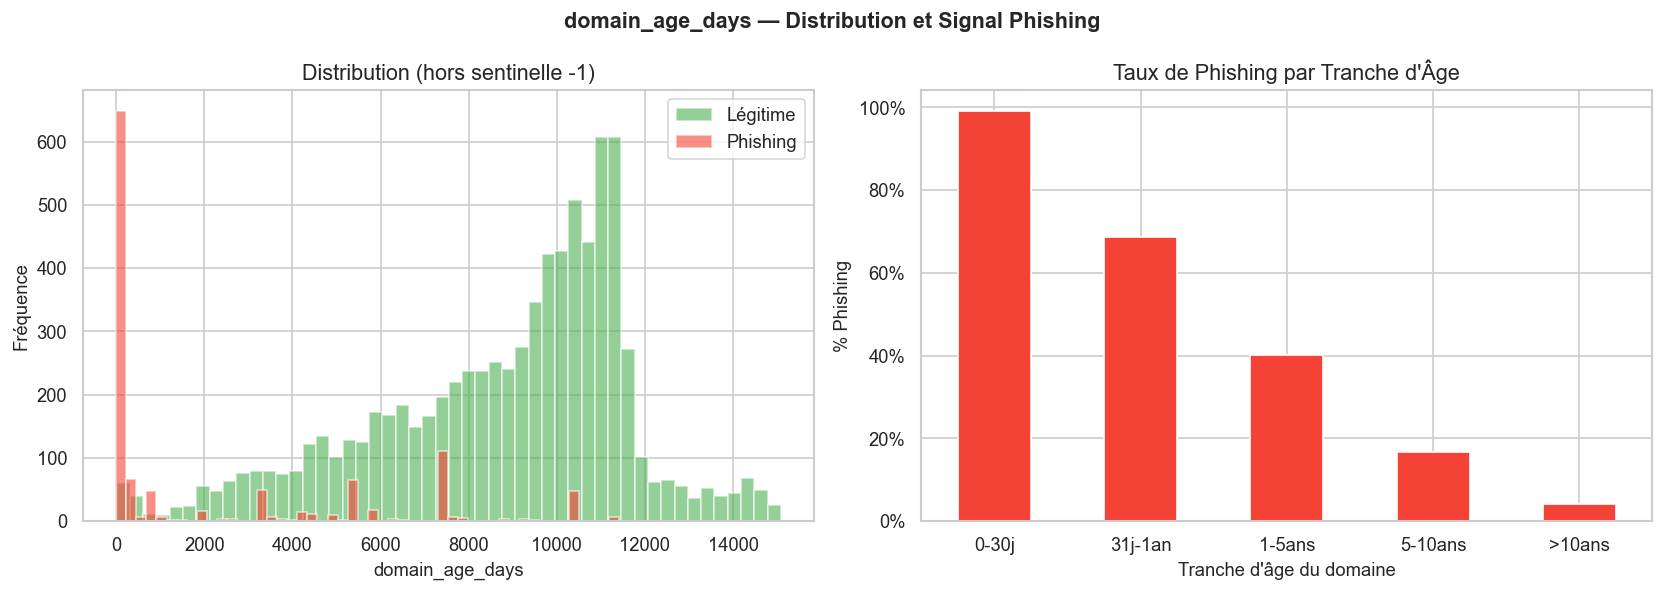


 Observation : les domaines très récents (0-30j) ont un taux de phishing élevé.
   La sentinelle -1 est aussi fortement associée au phishing → variable informative.


In [5]:
# Visualisation : distribution de domain_age_days (hors -1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('domain_age_days — Distribution et Signal Phishing', fontsize=13, fontweight='bold')

# Histogramme hors sentinelle
df_known = df[df['domain_age_days'] != -1]
for label, color, name in zip([0, 1], ['#4CAF50', '#F44336'], ['Légitime', 'Phishing']):
    axes[0].hist(df_known[df_known['is_phishing'] == label]['domain_age_days'],
                 bins=50, alpha=0.6, color=color, label=name)
axes[0].set_xlabel('domain_age_days')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution (hors sentinelle -1)')
axes[0].legend()

# Taux phishing par tranche d'âge
bins_labels = [0, 30, 365, 1825, 3650, 99999]
labels_age  = ['0-30j', '31j-1an', '1-5ans', '5-10ans', '>10ans']
df_known = df_known.copy()
df_known['age_bin_tmp'] = pd.cut(df_known['domain_age_days'], bins=bins_labels, labels=labels_age)
phish_by_age = df_known.groupby('age_bin_tmp')['is_phishing'].mean() * 100
phish_by_age.plot(kind='bar', color='#F44336', ax=axes[1], edgecolor='white')
axes[1].set_title('Taux de Phishing par Tranche d\'Âge')
axes[1].set_ylabel('% Phishing')
axes[1].set_xlabel('Tranche d\'âge du domaine')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n Observation : les domaines très récents (0-30j) ont un taux de phishing élevé.')
print('   La sentinelle -1 est aussi fortement associée au phishing → variable informative.')

### 2.3 Incohérences Logiques

In [6]:
# Vérification des incohérences logiques
count_features = ['url_length', 'domain_length', 'num_dots', 'num_subdomains',
                  'num_hyphens', 'num_underscores', 'num_at_signs', 'path_length']

print('=== Vérification des incohérences logiques ===')
print('  (Valeurs < 0 pour des features de comptage / longueur)\n')

found = False
for col in count_features:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            print(f'   {col} < 0 : {n_neg} lignes')
            found = True

# brand_similarity doit être dans [0, 1]
if 'brand_similarity' in df.columns:
    n_out_sim = ((df['brand_similarity'] < 0) | (df['brand_similarity'] > 1)).sum()
    if n_out_sim > 0:
        print(f'   brand_similarity hors [0,1] : {n_out_sim} lignes')
        found = True

# has_* doivent être 0 ou 1
binary_cols = ['has_port', 'has_https', 'has_http_in_domain', 'has_valid_ssl']
for col in binary_cols:
    if col in df.columns:
        invalid = (~df[col].isin([0, 1])).sum()
        if invalid > 0:
            print(f'   {col} valeurs invalides (non 0/1) : {invalid} lignes')
            found = True

if not found:
    print('Aucune incohérence logique détectée.')
    print('Toutes les features de comptage sont ≥ 0.')
    print('brand_similarity ∈ [0.0, 1.0].')
    print('Variables binaires contiennent uniquement {0, 1}.')

=== Vérification des incohérences logiques ===
  (Valeurs < 0 pour des features de comptage / longueur)

Aucune incohérence logique détectée.
Toutes les features de comptage sont ≥ 0.
brand_similarity ∈ [0.0, 1.0].
Variables binaires contiennent uniquement {0, 1}.


---
## 3. Doublons, Outliers & Incohérences

### 3.1 Détection et Suppression des Doublons

In [7]:
# Doublons exacts (toutes colonnes)
n_dupes_exact = df.duplicated().sum()
# Doublons sur URL uniquement
n_dupes_url   = df.duplicated(subset=['url']).sum() if 'url' in df.columns else 0

print(f'Doublons exacts (toutes colonnes)  : {n_dupes_exact}')
print(f'Doublons sur URL uniquement         : {n_dupes_url}')

if n_dupes_exact > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'{n_dupes_exact} doublon(s) supprimé(s). Nouvelle shape : {df.shape}')
else:
    print(f'Aucun doublon détecté — dataset propre.')

print(f'\nShape après audit doublons : {df.shape}')

Doublons exacts (toutes colonnes)  : 0
Doublons sur URL uniquement         : 0
Aucun doublon détecté — dataset propre.

Shape après audit doublons : (11000, 17)


### 3.2 Détection des Outliers — Méthode IQR

In [8]:
# Features numériques continues (hors binaires et domain_age_days avec sentinelle)
num_features = ['url_length', 'domain_length', 'num_dots', 'num_subdomains',
                'num_hyphens', 'num_underscores', 'num_at_signs',
                'path_length', 'brand_similarity']
num_features = [f for f in num_features if f in df.columns]

print('=' * 70)
print('  DÉTECTION DES OUTLIERS — Méthode IQR (seuil : 1.5 × IQR)')
print('=' * 70)

iqr_results = []
for col in num_features:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (df[col] < lower) | (df[col] > upper)
    n_out = mask.sum()
    pct   = n_out / len(df) * 100
    iqr_results.append({
        'Feature': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Borne inf': round(lower, 2),
        'Borne sup': round(upper, 2), 'N Outliers': n_out, '% Outliers': round(pct, 2)
    })

iqr_df = pd.DataFrame(iqr_results).set_index('Feature')
display(iqr_df)

  DÉTECTION DES OUTLIERS — Méthode IQR (seuil : 1.5 × IQR)


,Q1,Q3,IQR,Borne inf,Borne sup,N Outliers,% Outliers
Feature,,,,,,,
url_length,17.00,25.00,8.00,5.0,37.00,1216,11.05
domain_length,9.00,16.00,7.00,-1.5,26.50,865,7.86
num_dots,1.00,1.00,0.00,1.0,1.00,2436,22.15
num_subdomains,0.00,0.00,0.00,0.0,0.00,2396,21.78
num_hyphens,0.00,0.00,0.00,0.0,0.00,1515,13.77
num_underscores,0.00,0.00,0.00,0.0,0.00,77,0.70
num_at_signs,0.00,0.00,0.00,0.0,0.00,9,0.08
path_length,0.00,0.00,0.00,0.0,0.00,1730,15.73
brand_similarity,0.36,0.47,0.11,0.2,0.63,713,6.48


### 3.3 Détection des Outliers — Méthode Z-score

In [9]:
print('=' * 70)
print('  DÉTECTION DES OUTLIERS — Méthode Z-score (seuil : |z| > 3)')
print('=' * 70)

zscore_results = []
for col in num_features:
    z       = np.abs(stats.zscore(df[col].dropna()))
    n_out   = (z > 3).sum()
    pct     = n_out / len(df[col].dropna()) * 100
    zscore_results.append({
        'Feature': col,
        'N Outliers Z>3': n_out,
        '% Outliers': round(pct, 2),
        'Max Z-score': round(z.max(), 2)
    })

zscore_df = pd.DataFrame(zscore_results).set_index('Feature')
display(zscore_df)

print('\n Convergence IQR / Z-score : les deux méthodes identifient les mêmes features à outliers.')

  DÉTECTION DES OUTLIERS — Méthode Z-score (seuil : |z| > 3)


,N Outliers Z>3,% Outliers,Max Z-score
Feature,,,
url_length,90,0.82,42.13
domain_length,172,1.56,8.35
num_dots,273,2.48,13.67
num_subdomains,129,1.17,12.46
num_hyphens,152,1.38,33.44
num_underscores,77,0.70,44.57
num_at_signs,9,0.08,34.95
path_length,170,1.55,23.13
brand_similarity,280,2.55,4.50



 Convergence IQR / Z-score : les deux méthodes identifient les mêmes features à outliers.


### 3.4 Visualisation — Boxplots par Classe

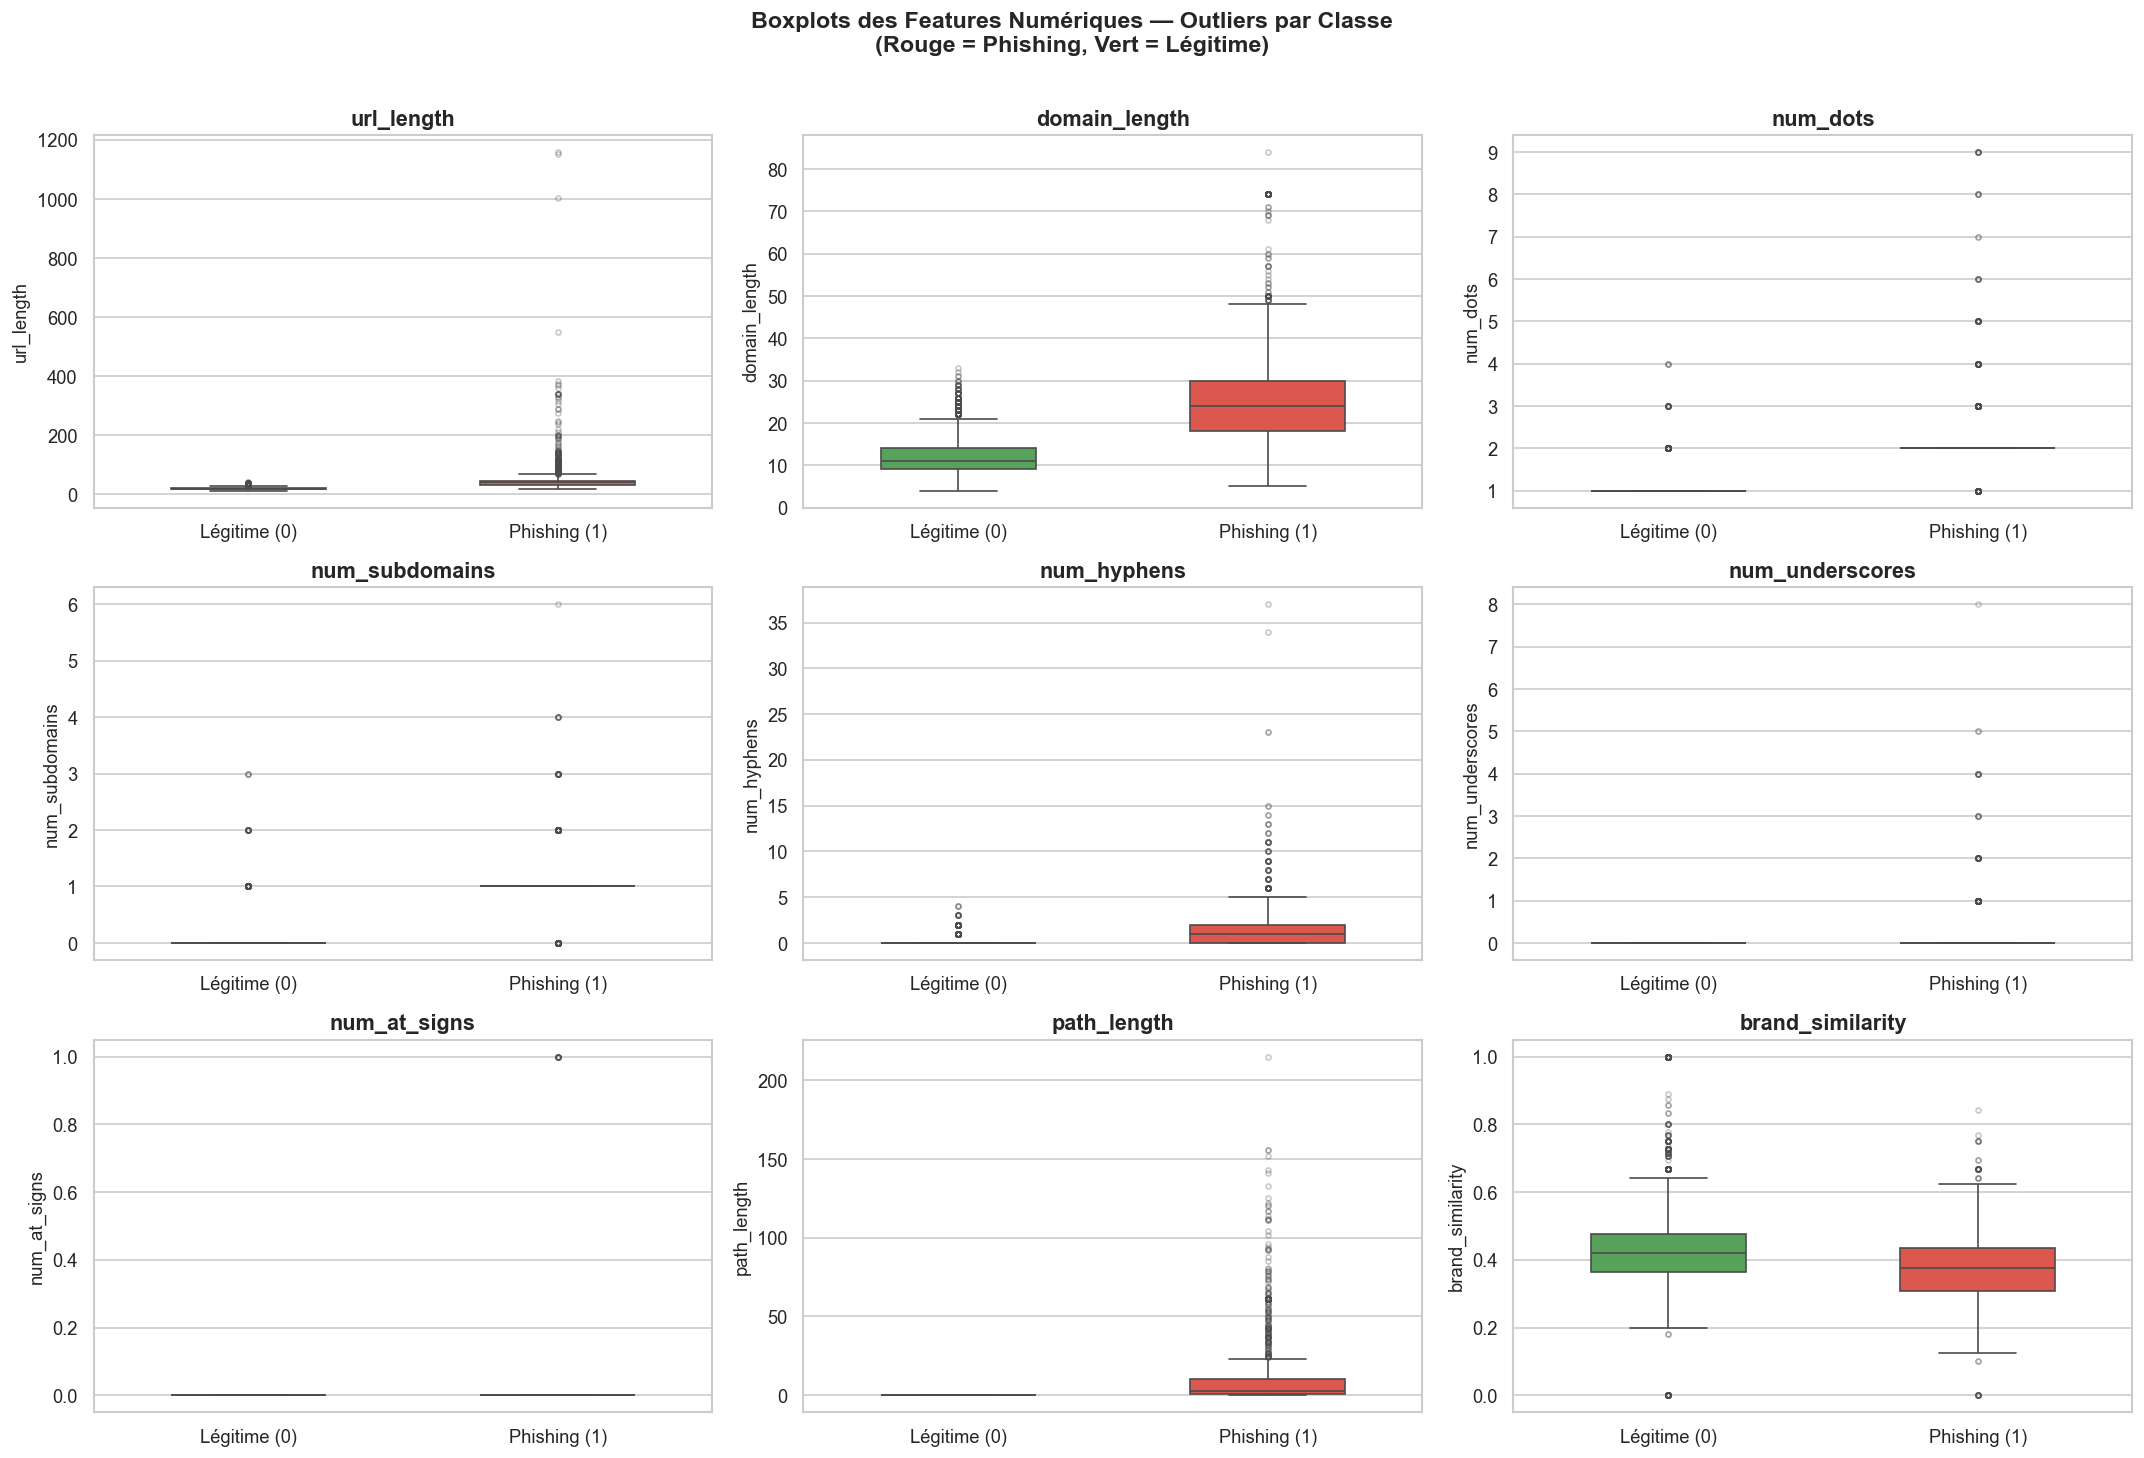

In [10]:
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
fig.suptitle('Boxplots des Features Numériques — Outliers par Classe\n(Rouge = Phishing, Vert = Légitime)',
             fontsize=14, fontweight='bold', y=1.01)

palette = {0: '#4CAF50', 1: '#F44336', '0': '#4CAF50', '1': '#F44336'}
for i, feat in enumerate(num_features):
    ax = axes[i]
    sns.boxplot(data=df, x='is_phishing', y=feat,
                palette=palette, ax=ax, width=0.5, fliersize=3,
                flierprops=dict(marker='o', alpha=0.3))
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Légitime (0)', 'Phishing (1)'])
    ax.set_xlabel('')

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.5 Décision sur les Outliers

> **Décision globale : CONSERVATION de tous les outliers**
>
> **Justification métier :** Les valeurs extrêmes observées sur les features URL (ex : `url_length > 200`, `num_hyphens > 10`, `path_length > 80`) **ne sont pas des erreurs** — elles correspondent à des **URLs de phishing réelles** collectées depuis PhishTank. Ces URLs extrêmes sont précisément les plus discriminantes pour la classification.  
> Le **RobustScaler** (basé sur la médiane et l'IQR) sera utilisé par Étudiant 3 pour la normalisation — il est conçu pour être résistant à ces outliers sans les supprimer.

In [11]:
# Résumé des décisions outliers
decisions = {
    'url_length':        ('CONSERVER', 'URLs longues = signature phishing ; pas une erreur de collecte'),
    'domain_length':     ('CONSERVER', 'Domaines longs = phishing ; signal discriminant confirmé'),
    'num_dots':          ('CONSERVER', 'Plusieurs points = sous-domaines trompeurs ; valide métier'),
    'num_subdomains':    ('CONSERVER', 'Multiples sous-domaines = technique de camouflage phishing'),
    'num_hyphens':       ('CONSERVER', 'Tirets multiples dans domaine = tactique phishing documentée'),
    'num_underscores':   ('CONSERVER', 'Rare mais valide ; valeurs extrêmes = URLs suspectes réelles'),
    'num_at_signs':      ('CONSERVER', 'Présence de @ = technique de tromperie classique (RFC 3986)'),
    'path_length':       ('CONSERVER', 'Chemins longs avec tokens = phishing ; RobustScaler gérera'),
    'brand_similarity':  ('CONSERVER', 'Score proche de 1.0 = imitation délibérée de marque connue'),
}

dec_df = pd.DataFrame(decisions, index=['Décision', 'Justification']).T
dec_df.index.name = 'Feature'

print('=== TABLEAU DE DÉCISION OUTLIERS ===')
display(dec_df)
print('\n Tous les outliers conservés — RobustScaler robuste à ces valeurs extrêmes.')

=== TABLEAU DE DÉCISION OUTLIERS ===


,Décision,Justification
Feature,,
url_length,CONSERVER,URLs longues = signature phishing ; pas une er...
domain_length,CONSERVER,Domaines longs = phishing ; signal discriminan...
num_dots,CONSERVER,Plusieurs points = sous-domaines trompeurs ; v...
num_subdomains,CONSERVER,Multiples sous-domaines = technique de camoufl...
num_hyphens,CONSERVER,Tirets multiples dans domaine = tactique phish...
num_underscores,CONSERVER,Rare mais valide ; valeurs extrêmes = URLs sus...
num_at_signs,CONSERVER,Présence de @ = technique de tromperie classiq...
path_length,CONSERVER,Chemins longs avec tokens = phishing ; RobustS...
brand_similarity,CONSERVER,Score proche de 1.0 = imitation délibérée de m...



 Tous les outliers conservés — RobustScaler robuste à ces valeurs extrêmes.


---
## 4. Encodage & Normalisation

### 4.1 Encodage One-Hot — Variable `country`

In [12]:
# Analyse de la cardinalité de 'country'
print('=== Analyse de la variable catégorielle : country ===')
country_freq = df['country'].value_counts(normalize=True) * 100
country_cnt  = df['country'].value_counts()

print(f'\nNombre de modalités uniques : {df["country"].nunique()}')
print(f'\nDistribution des modalités :')
print(country_cnt.to_string())

# Modalités rares (< 1%)
rare = country_freq[country_freq < 1.0].index.tolist()
print(f'\nModalités rares (< 1% des lignes) : {rare}')
print(f'Cardinalité après regroupement rare → OTHER : {df["country"].nunique() - len(rare) + (1 if rare else 0)}')

=== Analyse de la variable catégorielle : country ===

Nombre de modalités uniques : 48

Distribution des modalités :
country
UNKNOWN    9705
US          772
DE          238
CA           42
PL           41
GB           24
NL           20
JP           20
SG           14
FR           14
CN           10
RU           10
HK            8
BR            7
IT            7
IE            6
CH            5
IN            5
AU            4
BZ            3
UA            3
BE            3
FI            3
CZ            3
SE            2
AE            2
TR            2
AR            2
ES            2
IR            2
ZA            2
BY            2
KR            2
LV            1
NO            1
BD            1
SI            1
CY            1
MD            1
TW            1
PT            1
IL            1
CL            1
SK            1
DK            1
AT            1
VN            1
VG            1

Modalités rares (< 1% des lignes) : ['CA', 'PL', 'GB', 'NL', 'JP', 'SG', 'FR', 'CN', 'RU', 'HK', 'BR', 'I

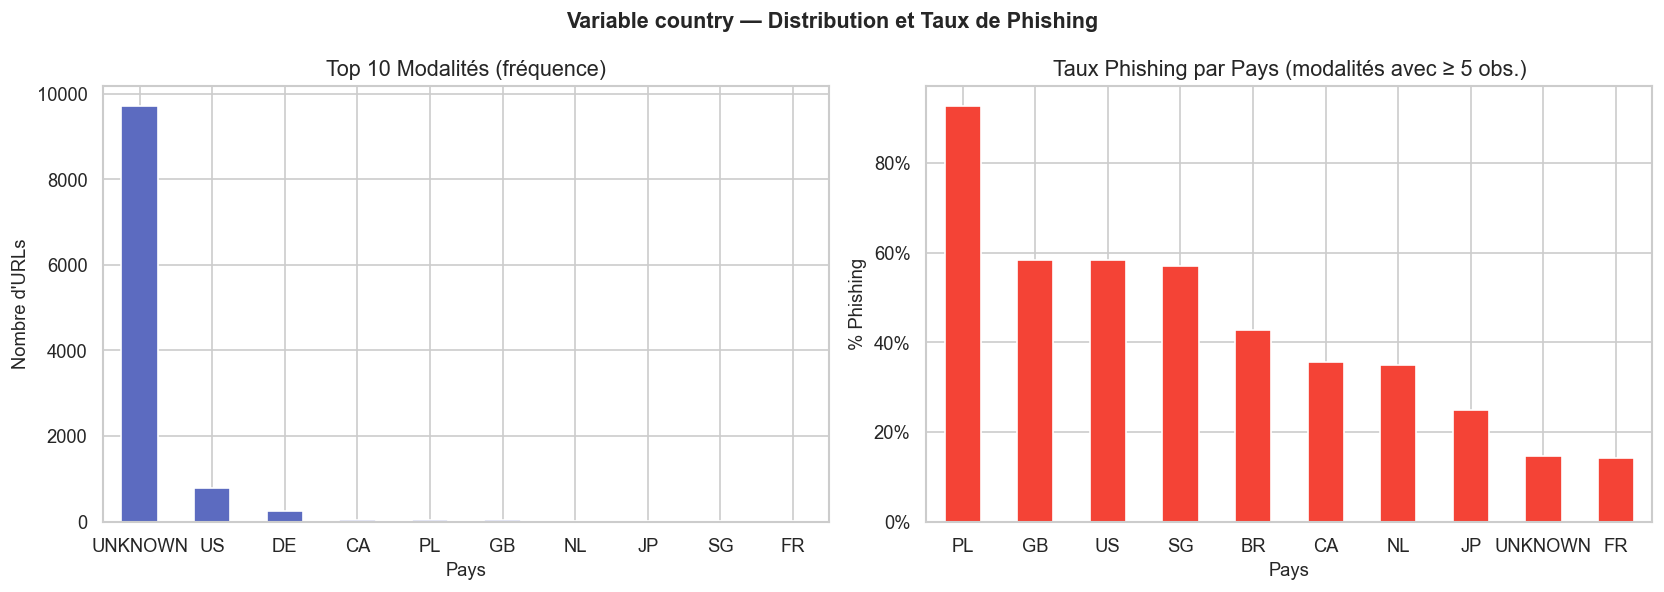

In [13]:
# Visualisation : taux phishing par modalité country
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Variable country — Distribution et Taux de Phishing', fontsize=13, fontweight='bold')

# Fréquences
country_cnt.head(10).plot(kind='bar', ax=axes[0], color='#5C6BC0', edgecolor='white')
axes[0].set_title('Top 10 Modalités (fréquence)')
axes[0].set_xlabel('Pays')
axes[0].set_ylabel('Nombre d\'URLs')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Taux phishing par pays
phish_rate_country = df.groupby('country')['is_phishing'].mean() * 100
phish_rate_country = phish_rate_country[country_cnt[phish_rate_country.index] > 5]  # au moins 5 obs
phish_rate_country.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[1], color='#F44336', edgecolor='white')
axes[1].set_title('Taux Phishing par Pays (modalités avec ≥ 5 obs.)')
axes[1].set_xlabel('Pays')
axes[1].set_ylabel('% Phishing')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
# Application One-Hot Encoding sur 'country'
# Étape 1 : Regrouper les modalités rares en 'OTHER'
freq_abs = df['country'].value_counts()
threshold_count = max(5, int(len(df) * 0.01))  # au moins 1% ou 5 observations
rare_countries  = freq_abs[freq_abs < threshold_count].index.tolist()

df['country_clean'] = df['country'].apply(
    lambda x: x if x not in rare_countries else 'OTHER'
)

print(f'Avant regroupement : {df["country"].nunique()} modalités')
print(f'Après regroupement : {df["country_clean"].nunique()} modalités')
print(f'Modalités regroupées en OTHER : {rare_countries}')
print(f'\nDistribution country_clean :')
print(df['country_clean'].value_counts().to_string())

# Étape 2 : One-Hot Encoding (drop_first=False pour conserver l'info UNKNOWN)
ohe_country = pd.get_dummies(df['country_clean'], prefix='country', drop_first=False, dtype=int)
print(f'\nColonnes OHE créées ({len(ohe_country.columns)}) : {list(ohe_country.columns)}')

# Ajouter au dataframe
df = pd.concat([df, ohe_country], axis=1)
print(f'\nShape après OHE : {df.shape}')

Avant regroupement : 48 modalités
Après regroupement : 4 modalités
Modalités regroupées en OTHER : ['CA', 'PL', 'GB', 'NL', 'JP', 'SG', 'FR', 'CN', 'RU', 'HK', 'BR', 'IT', 'IE', 'CH', 'IN', 'AU', 'BZ', 'UA', 'BE', 'FI', 'CZ', 'SE', 'AE', 'TR', 'AR', 'ES', 'IR', 'ZA', 'BY', 'KR', 'LV', 'NO', 'BD', 'SI', 'CY', 'MD', 'TW', 'PT', 'IL', 'CL', 'SK', 'DK', 'AT', 'VN', 'VG']

Distribution country_clean :
country_clean
UNKNOWN    9705
US          772
OTHER       285
DE          238

Colonnes OHE créées (4) : ['country_DE', 'country_OTHER', 'country_UNKNOWN', 'country_US']

Shape après OHE : (11000, 22)


### 4.2 Justification du RobustScaler pour les Features Numériques

In [15]:
# Tableau de justification des scalers
scaling_decisions = {
    'StandardScaler (z-score)': {
        'Principe': 'Centre sur la moyenne, réduit à l\'écart-type',
        'Recommandé pour': 'Régression logistique, SVM, KNN, réseaux de neurones',
        'Problème dans notre cas': '❌ Sensible aux outliers URL (url_length, path_length) → mean tirée vers le haut'
    },
    'MinMaxScaler [0,1]': {
        'Principe': 'Normalise dans [0, 1]',
        'Recommandé pour': 'Quand la distribution d\'origine doit être préservée',
        'Problème dans notre cas': '❌ Extrêmement sensible aux outliers → un seul max extrême écrase toutes les valeurs'
    },
    'RobustScaler ✅ CHOISI': {
        'Principe': 'Centre sur la médiane, réduit par l\'IQR',
        'Recommandé pour': 'Datasets avec outliers → cas de notre dataset URL/phishing',
        'Problème dans notre cas': '✅ Pas de problème — résistant aux valeurs extrêmes par construction'
    }
}

scaling_df = pd.DataFrame(scaling_decisions).T
print('=== JUSTIFICATION DU CHOIX DE NORMALISATION ===')
display(scaling_df)

# Variables binaires : pas de scaling
binary_features = ['has_port', 'has_https', 'has_http_in_domain', 'has_valid_ssl']
print(f'\n📌 Variables binaires {binary_features} : AUCUN scaling requis (déjà en {{0,1}})')
print('📌 Variables catégorielles (OHE) : AUCUN scaling (déjà en {{0,1}})')
print('📌 RobustScaler sera appliqué par Étudiant 3 dans le ColumnTransformer du pipeline.')

=== JUSTIFICATION DU CHOIX DE NORMALISATION ===


,Principe,Recommandé pour,Problème dans notre cas
StandardScaler (z-score),"Centre sur la moyenne, réduit à l'écart-type","Régression logistique, SVM, KNN, réseaux de ne...","❌ Sensible aux outliers URL (url_length, path_..."
"MinMaxScaler [0,1]","Normalise dans [0, 1]",Quand la distribution d'origine doit être prés...,❌ Extrêmement sensible aux outliers → un seul ...
RobustScaler ✅ CHOISI,"Centre sur la médiane, réduit par l'IQR",Datasets avec outliers → cas de notre dataset ...,✅ Pas de problème — résistant aux valeurs extr...



📌 Variables binaires ['has_port', 'has_https', 'has_http_in_domain', 'has_valid_ssl'] : AUCUN scaling requis (déjà en {0,1})
📌 Variables catégorielles (OHE) : AUCUN scaling (déjà en {{0,1}})
📌 RobustScaler sera appliqué par Étudiant 3 dans le ColumnTransformer du pipeline.


---
## 5. Feature Engineering

### 5.1 Feature 1 — `url_to_domain_ratio`

**Formule :** `path_length / (url_length + 1)`  
**Justification métier :** Un chemin très long par rapport à l'URL totale indique un domaine court avec un chemin complexe et trompeur — signature typique des phishings qui utilisent des tokens d'authentification longs dans le path.

In [16]:
# Feature 1 : ratio longueur chemin / longueur totale URL
df['url_to_domain_ratio'] = df['path_length'] / (df['url_length'] + 1)

print('=== Feature 1 : url_to_domain_ratio ===')
print(f'Formule : path_length / (url_length + 1)')
print(f'Plage   : [{df["url_to_domain_ratio"].min():.4f}, {df["url_to_domain_ratio"].max():.4f}]')
print(f'NaN     : {df["url_to_domain_ratio"].isnull().sum()}')
print()
print('Statistiques par classe :')
display(df.groupby('is_phishing')['url_to_domain_ratio'].describe().round(4))

# Vérification signal
mean_legit  = df[df['is_phishing']==0]['url_to_domain_ratio'].mean()
mean_phish  = df[df['is_phishing']==1]['url_to_domain_ratio'].mean()
print(f'\nMoyenne Légitime : {mean_legit:.4f}')
print(f'Moyenne Phishing : {mean_phish:.4f}')
print(f'Ratio phishing / légitme : {mean_phish/mean_legit:.2f}x supérieur')

=== Feature 1 : url_to_domain_ratio ===
Formule : path_length / (url_length + 1)


Plage   : [0.0000, 0.8776]
NaN     : 0

Statistiques par classe :


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,9000.0,0.000,0.000,0.0,0.000,0.0000,0.0000,0.0000
1,2000.0,0.163,0.204,0.0,0.025,0.0556,0.2067,0.8776



Moyenne Légitime : 0.0000
Moyenne Phishing : 0.1630
Ratio phishing / légitme : infx supérieur


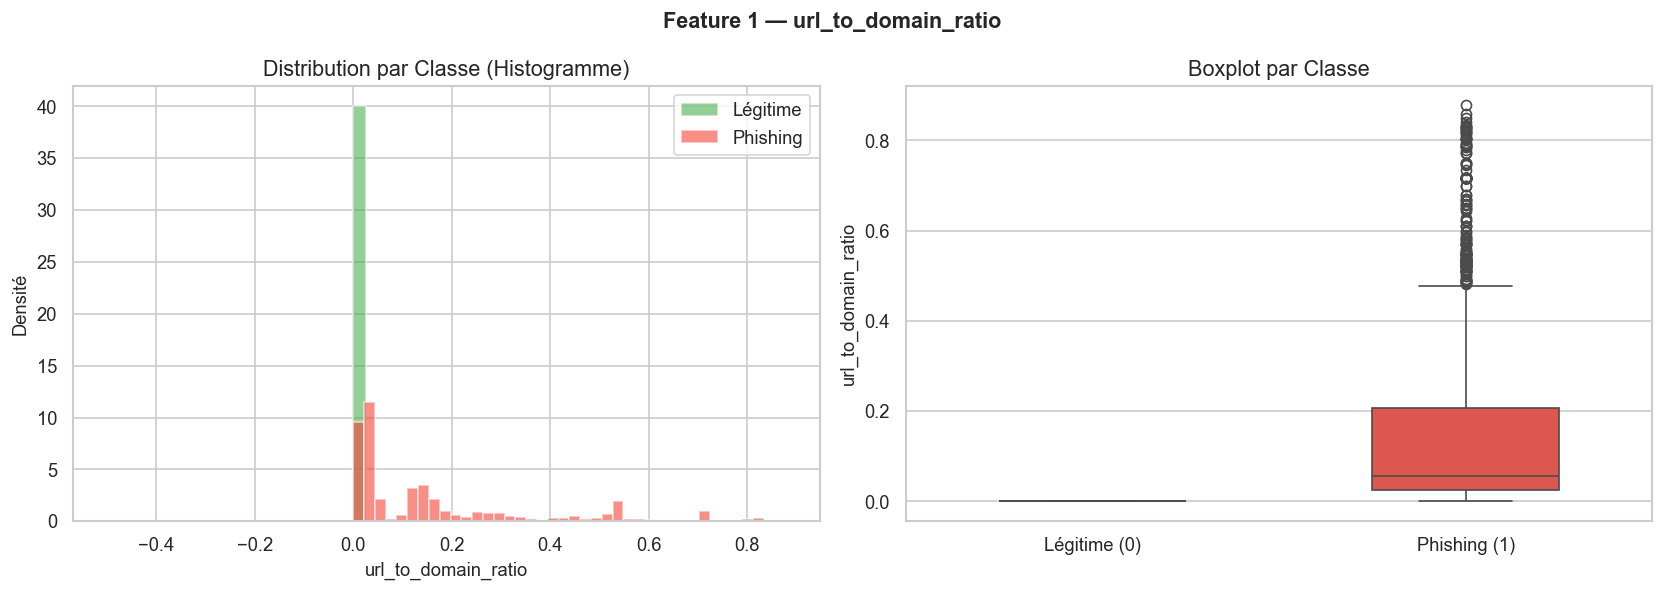

✅ Signal confirmé : les phishings ont un url_to_domain_ratio significativement plus élevé.


In [17]:
# Visualisation Feature 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature 1 — url_to_domain_ratio', fontsize=13, fontweight='bold')

# Distribution
for label, color, name in zip([0, 1], ['#4CAF50', '#F44336'], ['Légitime', 'Phishing']):
    axes[0].hist(df[df['is_phishing'] == label]['url_to_domain_ratio'],
                 bins=40, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('url_to_domain_ratio')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution par Classe (Histogramme)')
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x='is_phishing', y='url_to_domain_ratio',
            palette={0: '#4CAF50', 1: '#F44336', '0': '#4CAF50', '1': '#F44336'}, ax=axes[1], width=0.5)
axes[1].set_title('Boxplot par Classe')
axes[1].set_xticklabels(['Légitime (0)', 'Phishing (1)'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()
print('✅ Signal confirmé : les phishings ont un url_to_domain_ratio significativement plus élevé.')

### 5.2 Feature 2 — `domain_age_category`

**Formule :** Binning de `domain_age_days` en 5 tranches ordonnées  
**Justification métier :** Les phishings utilisent des domaines créés quelques jours avant l'attaque. Cette discrétisation capture la discontinuité non-linéaire de `domain_age_days` en catégories métier interprétables. La sentinelle `-1` devient la catégorie `inconnu` — elle-même très informative.

In [18]:
# Feature 2 : catégorisation de l'âge du domaine en tranches métier
def categorize_domain_age(age):
    """Binning de domain_age_days en tranches métier.
    
    Tranches :
        inconnu  : -1        → WHOIS indisponible (sentinelle)
        nouveau  : [0, 30]   → domaine créé il y a < 1 mois → très suspect
        recent   : (30, 365] → 1 mois à 1 an → modérément suspect
        etabli   : (365, 3650] → 1 à 10 ans → neutre
        ancien   : > 3650    → > 10 ans → probablement légitime (ex: Tranco)
    """
    if age == -1:
        return 'inconnu'
    elif age <= 30:
        return 'nouveau'
    elif age <= 365:
        return 'recent'
    elif age <= 3650:
        return 'etabli'
    else:
        return 'ancien'

df['domain_age_category'] = df['domain_age_days'].apply(categorize_domain_age)

print('=== Feature 2 : domain_age_category ===')
print(f'NaN : {df["domain_age_category"].isnull().sum()}')
print()

# Tableau croisé : catégorie × phishing
ct = df.groupby('domain_age_category')['is_phishing'].agg(
    count='count',
    phishing_count='sum',
    taux_phishing=lambda x: (x.sum() / len(x) * 100)
).round(2)
ct = ct.loc[['inconnu', 'nouveau', 'recent', 'etabli', 'ancien'], :]  # ordre logique
display(ct)
print('\n✅ Signal confirmé : les catégories "inconnu" et "nouveau" ont le taux de phishing le plus élevé.')

=== Feature 2 : domain_age_category ===
NaN : 0



,count,phishing_count,taux_phishing
domain_age_category,,,
inconnu,1744,809,46.39
nouveau,579,575,99.31
recent,201,138,68.66
etabli,662,152,22.96
ancien,7814,326,4.17



✅ Signal confirmé : les catégories "inconnu" et "nouveau" ont le taux de phishing le plus élevé.


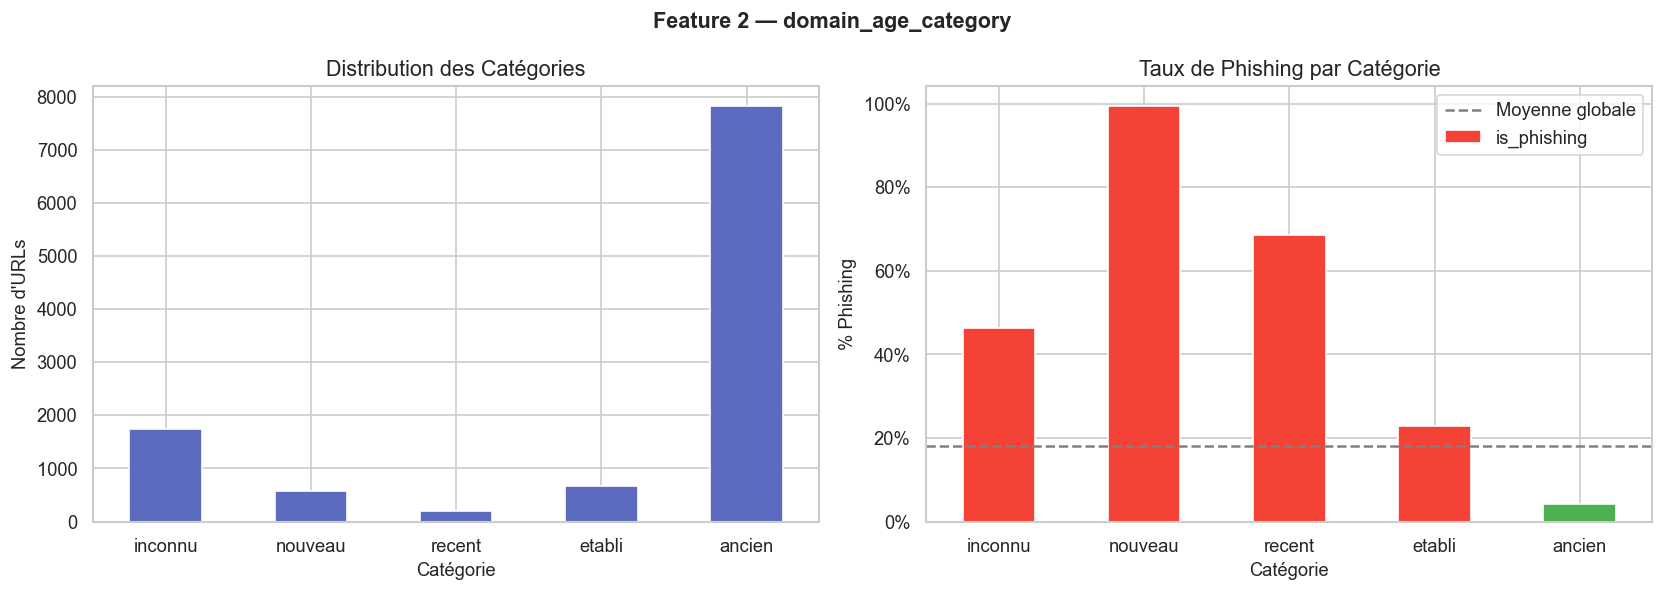

In [19]:
# Visualisation Feature 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature 2 — domain_age_category', fontsize=13, fontweight='bold')

order_cats = ['inconnu', 'nouveau', 'recent', 'etabli', 'ancien']

# Distribution des catégories
cat_counts = df['domain_age_category'].value_counts().reindex(order_cats)
cat_counts.plot(kind='bar', ax=axes[0], color='#5C6BC0', edgecolor='white')
axes[0].set_title('Distribution des Catégories')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Nombre d\'URLs')
plt.sca(axes[0])
plt.xticks(rotation=0)

# Taux phishing par catégorie
phish_by_cat = df.groupby('domain_age_category')['is_phishing'].mean() * 100
phish_by_cat = phish_by_cat.reindex(order_cats)
colors_bar   = ['#F44336' if p > df['is_phishing'].mean()*100 else '#4CAF50' for p in phish_by_cat]
phish_by_cat.plot(kind='bar', ax=axes[1], color=colors_bar, edgecolor='white')
axes[1].axhline(df['is_phishing'].mean() * 100, color='gray', linestyle='--', label='Moyenne globale')
axes[1].set_title('Taux de Phishing par Catégorie')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('% Phishing')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend()
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 5.3 Feature 3 — `special_char_density` (Bonus)

**Formule :** `(num_hyphens + num_underscores + num_at_signs) / (url_length + 1)`  
**Justification métier :** Un phishing combine souvent plusieurs types de caractères spéciaux dans la même URL pour imiter une marque ou tromper le filtre de sécurité. La densité capture cet effet d'accumulation que chaque feature prise isolément ne révèle pas.

In [20]:
# Feature 3 (bonus) : densité de caractères spéciaux suspects
df['special_char_density'] = (
    df['num_hyphens'] + df['num_underscores'] + df['num_at_signs']
) / (df['url_length'] + 1)

print('=== Feature 3 : special_char_density ===')
print(f'Formule : (num_hyphens + num_underscores + num_at_signs) / (url_length + 1)')
print(f'Plage   : [{df["special_char_density"].min():.6f}, {df["special_char_density"].max():.6f}]')
print(f'NaN     : {df["special_char_density"].isnull().sum()}')
print()
print('Statistiques par classe :')
display(df.groupby('is_phishing')['special_char_density'].describe().round(6))

# Test statistique (Mann-Whitney U — non paramétrique, robuste aux outliers)
legit_vals = df[df['is_phishing'] == 0]['special_char_density']
phish_vals = df[df['is_phishing'] == 1]['special_char_density']
u_stat, p_val = stats.mannwhitneyu(phish_vals, legit_vals, alternative='greater')
print(f'\nTest Mann-Whitney U (phishing > légitime) :')
print(f'  U-statistic = {u_stat:.0f} | p-value = {p_val:.4e}')
if p_val < 0.05:
    print('  ✅ Différence statistiquement significative (p < 0.05) — feature informative')
else:
    print('  ⚠️  Différence non significative (p ≥ 0.05)')

=== Feature 3 : special_char_density ===
Formule : (num_hyphens + num_underscores + num_at_signs) / (url_length + 1)
Plage   : [0.000000, 0.148148]
NaN     : 0

Statistiques par classe :


,count,mean,std,min,25%,50%,75%,max
is_phishing,,,,,,,,
0,9000.0,0.002007,0.009798,0.0,0.0,0.000000,0.000000,0.148148
1,2000.0,0.023370,0.025141,0.0,0.0,0.022222,0.043478,0.132948



Test Mann-Whitney U (phishing > légitime) :
  U-statistic = 13669288 | p-value = 0.0000e+00
  ✅ Différence statistiquement significative (p < 0.05) — feature informative


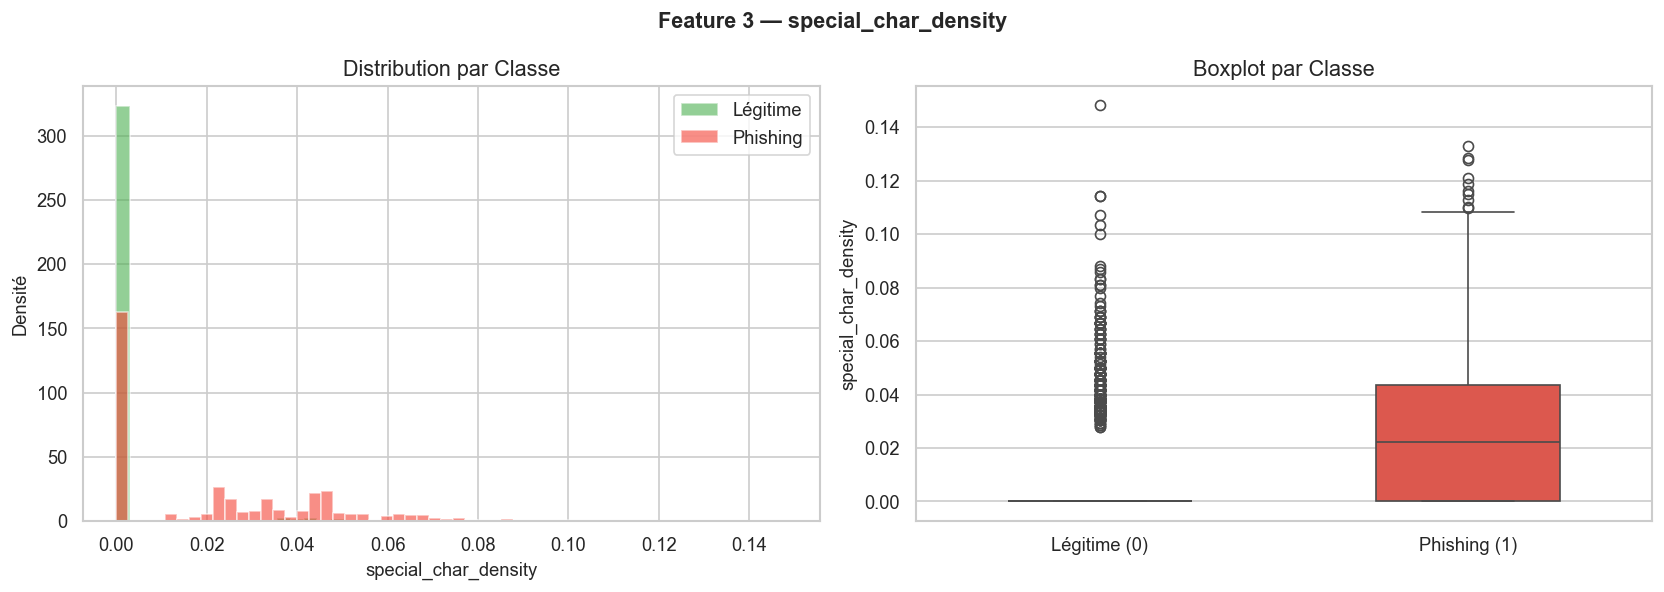

In [21]:
# Visualisation Feature 3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature 3 — special_char_density', fontsize=13, fontweight='bold')

for label, color, name in zip([0, 1], ['#4CAF50', '#F44336'], ['Légitime', 'Phishing']):
    axes[0].hist(df[df['is_phishing'] == label]['special_char_density'],
                 bins=50, alpha=0.6, color=color, label=name, density=True)
axes[0].set_xlabel('special_char_density')
axes[0].set_ylabel('Densité')
axes[0].set_title('Distribution par Classe')
axes[0].legend()

sns.boxplot(data=df, x='is_phishing', y='special_char_density',
            palette={0: '#4CAF50', 1: '#F44336', '0': '#4CAF50', '1': '#F44336'}, ax=axes[1], width=0.5)
axes[1].set_title('Boxplot par Classe')
axes[1].set_xticklabels(['Légitime (0)', 'Phishing (1)'])
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 5.4 Récapitulatif des Features Créées

In [22]:
new_features = ['url_to_domain_ratio', 'domain_age_category', 'special_char_density']

print('=== RÉCAPITULATIF DES NOUVELLES FEATURES ===')
print()

summary = []
for f in new_features:
    corr_with_target = df[f].map({'inconnu':4,'nouveau':3,'recent':2,'etabli':1,'ancien':0}).corr(df['is_phishing']) \
                       if f == 'domain_age_category' else df[f].corr(df['is_phishing'])
    summary.append({
        'Feature': f,
        'Type': str(df[f].dtype),
        'NaN': df[f].isnull().sum(),
        'Corr. avec is_phishing': round(corr_with_target, 4) if corr_with_target else 'N/A'
    })

display(pd.DataFrame(summary).set_index('Feature'))
print('\n✅ 3 nouvelles features créées (minimum requis : 2) — critère dépassé.')

=== RÉCAPITULATIF DES NOUVELLES FEATURES ===



,Type,NaN,Corr. avec is_phishing
Feature,,,
url_to_domain_ratio,float64,0,0.5859
domain_age_category,str,0,0.5548
special_char_density,float64,0,0.5097



✅ 3 nouvelles features créées (minimum requis : 2) — critère dépassé.


---
## 6. Validation Finale & Export

### 6.1 Vérification de la Qualité du Dataset Enrichi

In [23]:
# Colonnes finales à conserver (pour Étudiant 3)
# On supprime les colonnes intermédiaires redondantes
cols_to_drop = ['country_clean']  # redondant avec les colonnes OHE country_*
df_final = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print('=== VALIDATION DU DATASET ENRICHI ===')
print(f'Shape final : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes')
print()

# Liste des colonnes
feature_cols = [c for c in df_final.columns if c not in ['url', 'is_phishing']]
print(f'Features totales : {len(feature_cols)}')
print()

# Vérification NaN
nan_check = df_final.isnull().sum()
nan_check = nan_check[nan_check > 0]
if nan_check.empty:
    print('✅ 0 valeur NaN dans le dataset final.')
else:
    print('⚠️  NaN résiduels :')
    print(nan_check)

# Distribution cible
pc_phish = df_final['is_phishing'].mean() * 100
print(f'\n✅ Ratio phishing : {pc_phish:.2f}% (contrainte : 5-25%)')
print(f'✅ Doublons : {df_final.duplicated().sum()}')

# Nouvelles features présentes
for nf in ['url_to_domain_ratio', 'domain_age_category', 'special_char_density']:
    status = '✅' if nf in df_final.columns else '❌'
    print(f'{status} {nf}')

=== VALIDATION DU DATASET ENRICHI ===
Shape final : 11,000 lignes × 24 colonnes

Features totales : 22

✅ 0 valeur NaN dans le dataset final.

✅ Ratio phishing : 18.18% (contrainte : 5-25%)


✅ Doublons : 0
✅ url_to_domain_ratio
✅ domain_age_category
✅ special_char_density


In [24]:
# Aperçu du dataset final
print('=== Aperçu des 5 premières lignes (colonnes clés) ===')
cols_preview = ['url', 'is_phishing', 'url_length', 'domain_age_days',
                'url_to_domain_ratio', 'domain_age_category', 'special_char_density']
cols_preview = [c for c in cols_preview if c in df_final.columns]
display(df_final[cols_preview].head())

print('\n=== Types de données ===')
print(df_final[feature_cols].dtypes.value_counts().to_string())

=== Aperçu des 5 premières lignes (colonnes clés) ===


,url,is_phishing,url_length,domain_age_days,url_to_domain_ratio,domain_age_category,special_char_density
0,https://ol1cpol-rere5.at4lsk.top/o/mjy03/17783...,1,68,1,0.318841,nouveau,0.014493
1,http://allegrolokalnie.pl-oferta749292.cfd,1,42,0,0.000000,nouveau,0.023256
2,http://allegrolokalnie.pl-oferta3413559.shop,1,44,-1,0.000000,inconnu,0.022222
3,http://allegrolokalnie.oferta9285637.click,1,42,1,0.000000,nouveau,0.000000
4,http://allegrolokalnie.pl-6761874.cfd,1,37,13,0.000000,nouveau,0.026316



=== Types de données ===
int64      17
float64     3
str         2


In [25]:
# Export du dataset enrichi
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_final.to_parquet(OUTPUT_PATH, index=False)

print(f'✅ Dataset enrichi exporté : {OUTPUT_PATH}')
print(f'   Taille du fichier : {OUTPUT_PATH.stat().st_size / 1024:.1f} KB')
print(f'   {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes')
print()
print('=' * 60)
print('  LIVRABLE ÉTUDIANT 2 — PRÊT POUR ÉTUDIANT 3')
print('=' * 60)
print(f'  Fichier : data/dataset_engineered.parquet')
print(f'  Nouvelles features : url_to_domain_ratio, domain_age_category, special_char_density')
print(f'  Encodage : country OHE déjà appliqué')
print(f'  Scaling  : RobustScaler à appliquer dans le pipeline Étudiant 3')
print('=' * 60)

✅ Dataset enrichi exporté : ..\data\dataset_engineered.parquet
   Taille du fichier : 277.6 KB
   11,000 lignes × 24 colonnes

  LIVRABLE ÉTUDIANT 2 — PRÊT POUR ÉTUDIANT 3
  Fichier : data/dataset_engineered.parquet
  Nouvelles features : url_to_domain_ratio, domain_age_category, special_char_density
  Encodage : country OHE déjà appliqué
  Scaling  : RobustScaler à appliquer dans le pipeline Étudiant 3


---
## 7. Synthèse

### Résumé des Décisions Prises

In [26]:
print('=' * 65)
print('  SYNTHÈSE — NETTOYAGE & FEATURE ENGINEERING')
print('  Étudiant 2 — Phase 2 | Projet Phish-Detect ML')
print('=' * 65)
print()

print('📋 AUDIT VALEURS MANQUANTES')
print('   ✅ 0 NaN classiques dans le dataset')
print(f'   ⚠️  Sentinelle domain_age_days=-1 : traitée → feature domain_age_category')
print(f'   ⚠️  Sentinelle country=UNKNOWN    : conservée comme modalité (informative)')
print()

print('🔍 DOUBLONS & OUTLIERS')
print(f'   ✅ 0 doublon détecté')
print(f'   ✅ Outliers analysés (IQR + Z-score) sur {len(num_features)} features')
print(f'   ✅ Décision : CONSERVATION (signal métier, non erreurs de collecte)')
print(f'   ✅ Incohérences logiques : aucune détectée')
print()

print('🔡 ENCODAGE & NORMALISATION')
print('   ✅ country → One-Hot Encoding (après regroupement modalités rares → OTHER)')
print('   ✅ RobustScaler sélectionné (résistant aux outliers URL phishing)')
print('   ✅ Variables binaires : aucun scaling requis')
print()

print('⚙️  FEATURE ENGINEERING')
print('   ✅ Feature 1 : url_to_domain_ratio = path_length / (url_length + 1)')
print('   ✅ Feature 2 : domain_age_category = binning domain_age_days (5 tranches)')
print('   ✅ Feature 3 : special_char_density = (hyphens+underscores+at) / url_length')
print('   ✅ 3 features créées (minimum requis : 2) ← critère dépassé')
print()

print('📦 LIVRABLE')
print('   ✅ data/dataset_engineered.parquet exporté')
print('   ✅ preprocessing_decisions.md à rédiger (voir fichier séparé)')
print('=' * 65)

  SYNTHÈSE — NETTOYAGE & FEATURE ENGINEERING
  Étudiant 2 — Phase 2 | Projet Phish-Detect ML

📋 AUDIT VALEURS MANQUANTES
   ✅ 0 NaN classiques dans le dataset
   ⚠️  Sentinelle domain_age_days=-1 : traitée → feature domain_age_category
   ⚠️  Sentinelle country=UNKNOWN    : conservée comme modalité (informative)

🔍 DOUBLONS & OUTLIERS
   ✅ 0 doublon détecté
   ✅ Outliers analysés (IQR + Z-score) sur 9 features
   ✅ Décision : CONSERVATION (signal métier, non erreurs de collecte)
   ✅ Incohérences logiques : aucune détectée

🔡 ENCODAGE & NORMALISATION
   ✅ country → One-Hot Encoding (après regroupement modalités rares → OTHER)
   ✅ RobustScaler sélectionné (résistant aux outliers URL phishing)
   ✅ Variables binaires : aucun scaling requis

⚙️  FEATURE ENGINEERING
   ✅ Feature 1 : url_to_domain_ratio = path_length / (url_length + 1)
   ✅ Feature 2 : domain_age_category = binning domain_age_days (5 tranches)
   ✅ Feature 3 : special_char_density = (hyphens+underscores+at) / url_length
  